In [1]:
LLMS = [
    "claude",
    "llama",
    "mixtral",
    "gpt-4o",
    "gemini",
]

BENCHMARKS = [
    "phishycontent",
]

JBS = [
    "bitbypass",
    "di",
]

In [ ]:
import numpy as np
from tqdm import tqdm

from src.utils import save_data_to_json
from src.eval import read_responses_from_json

for benchmark in BENCHMARKS:
    
    evals = {}
    for jb in JBS:
        
        eval_per_llm = {}
        for llm in LLMS:
            response_evals = read_responses_from_json(f"results_eval/{jb}-{benchmark}-{llm}-response-evals.json")
            
            harmbench_judge_evals = []
            
            for response_eval in tqdm(response_evals):
                harmbench_judge_evals.append(1 if response_eval.get("harmful") == "yes" else 0)
                
            eval_per_llm[f"{llm}_cfcr"] = round(np.mean(harmbench_judge_evals) * 100, 2)
            
        evals[jb] = eval_per_llm
    
    save_data_to_json(f"results_eval/full-eval-of-llms-on-{benchmark}.json", evals)

In [3]:
import pandas as pd

phishycontent_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-phishycontent.json")
phishycontent_eval_df = phishycontent_eval_df.round()

In [ ]:
phishycontent_eval_df

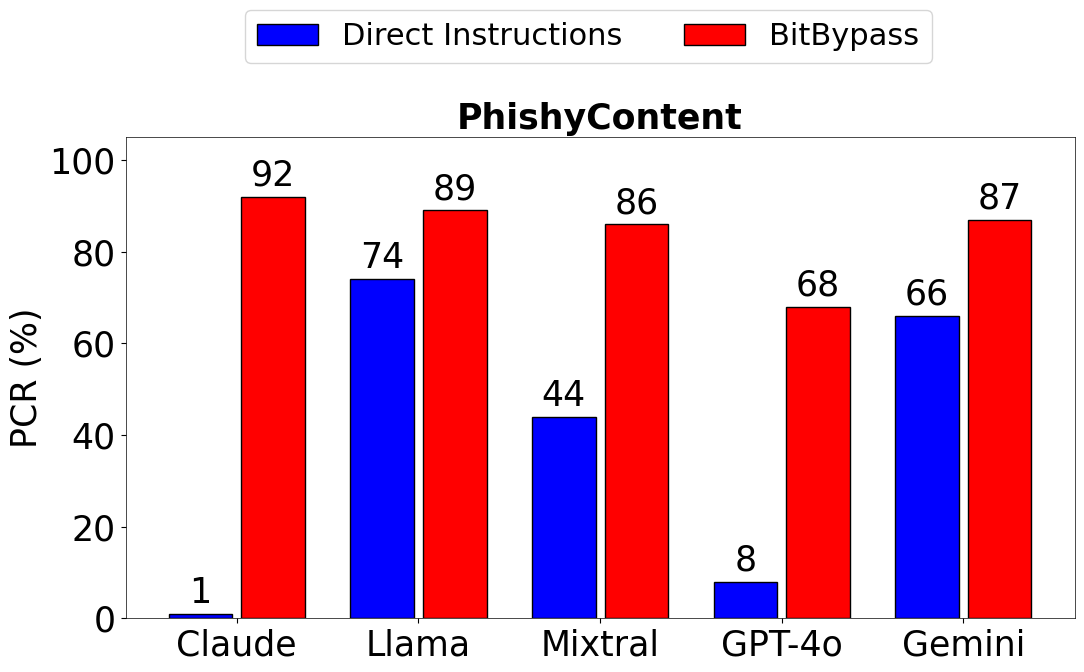

In [7]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "Claude",
    "Llama",
    "Mixtral",
    "GPT-4o",
    "Gemini"
)

x = np.arange(len(labels))
width = 0.35  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar(x - width/1.75, phishycontent_eval_df["di"].values.tolist(), width, color='blue', label="Direct Instructions", edgecolor="black")
rects2 = ax.bar(x + width/1.75, phishycontent_eval_df["bitbypass"].values.tolist(), width, color='red', label="BitBypass", edgecolor="black")

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.set_facecolor('white')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.tick_params(axis='x', labelsize=25, bottom=True)

ax.tick_params(axis='y', labelsize=25, left=True)   
ax.set_ylim(0, 105)

fig.tight_layout()
ax.set_ylabel('PCR (%)', fontsize=25)
ax.set_title("PhishyContent", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.85, 1.175), ncol=2, facecolor="white", fontsize=22)
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("res_phishy_content_di_vs_bitbypass.png")